In [2]:
import torch

import pandas as pd
data_folder = '../../data/'

data_CCSV=pd.read_csv(data_folder + "California_county_social_vuln.csv")
data_HUS=pd.read_csv(data_folder + "healthcare utilization summary data.csv")
print(data_CCSV.head())

   ST       STATE ST_ABBR  STCNTY            COUNTY  FIPS  \
0   6  California      CA    6001    Alameda County  6001   
1   6  California      CA    6003     Alpine County  6003   
2   6  California      CA    6005     Amador County  6005   
3   6  California      CA    6007      Butte County  6007   
4   6  California      CA    6009  Calaveras County  6009   

                       LOCATION    AREA_SQMI  E_TOTPOP  M_TOTPOP  ...  \
0    Alameda County, California   737.458877   1663823         0  ...   
1     Alpine County, California   738.340000      1515       206  ...   
2     Amador County, California   594.584366     40577         0  ...   
3      Butte County, California  1636.488966    213605         0  ...   
4  Calaveras County, California  1020.018688     45674         0  ...   

   EP_ASIAN  MP_ASIAN  EP_AIAN  MP_AIAN  EP_NHPI  MP_NHPI  EP_TWOMORE  \
0      31.9       0.1      0.3      0.1      0.7      0.1         5.0   
1       0.2       0.4     24.0      4.0      0.0

In [ ]:
#AreaID	Geographic area identifier, created by Milliman to statistically de-identify the data provided to the hackathon. Each area includes several adjacent counties. Refer to the "FIPS to AreaID Crosswalk" table. If field value is missing, the area is deemed unknown due to underlying data quality issues
# yearmo	Year-month
# LOB	Health insurance coverage type. ADV = Medicare Advantage. COM = Commercial. MCD = Medicaid
# RiskScore	Average health status risk score, generated by Milliman using the industry standard risk adjustment tool, MARA (https://www.milliman.com/en/products/mara). The higher the risk score, the greater healthcare resource needs. 
# E_UNINSUR	Estimated uninsured persons
# MED_ADMT_CNT	Count of medical admissions
# ED_ADMT_CNT	Count of emergency department visits
# UC_ADMT_CNT	Count of urgent care visits

HUS_cols=["AreaID", "LOB", "RiskScore", "E_UNINSUR", "MED_ADMT_CNT", "ED_ADMT_CNT", "UC_ADMT_CNT", "yearmo"]
print(data_HUS[HUS_cols].head())



In [3]:
# Here we calculate the socioeconomic status score by county by summing the proportion of vulnerable socioeconomic indicators

cols = ["E_POV150", "E_UNEMP", "E_HBURD", "E_NOHSDP", "E_UNINSUR"]
for col in cols:
    data_CCSV[f"{col}_prop"] = data_CCSV[col] / data_CCSV["E_TOTPOP"]

data_CCSV["Socioeconomic_status"] = data_CCSV[["E_UNEMP_prop", "E_POV150_prop", "E_HBURD_prop", "E_NOHSDP_prop", "E_UNINSUR_prop"]].sum(axis=1)
print(data_CCSV[["COUNTY","Socioeconomic_status"]].head())

             COUNTY  Socioeconomic_status
0    Alameda County              0.366097
1     Alpine County              0.349835
2     Amador County              0.395446
3      Butte County              0.564603
4  Calaveras County              0.474143


/home/nicholas/miniconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/nicholas/miniconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/nicholas/miniconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


                COUNTY  Socioeconomic_status
30       Placer County              0.287213
20        Marin County              0.300708
40    San Mateo County              0.301295
42  Santa Clara County              0.308737
8     El Dorado County              0.336785


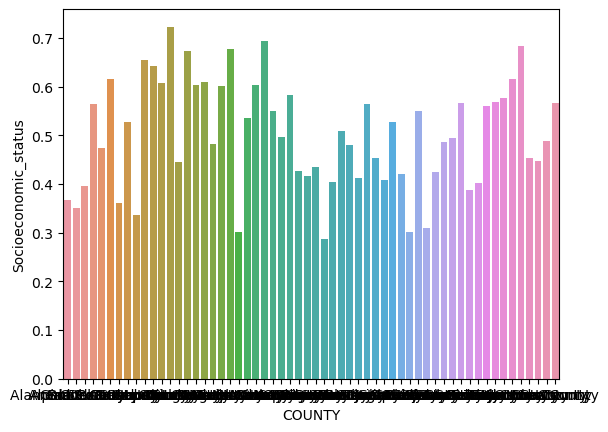

In [5]:
# Some basic visualizing and sorting
import seaborn as sns
sns.barplot(data, x="COUNTY", y="Socioeconomic_status")
data_ranked = data.sort_values(by="Socioeconomic_status")
print(data_ranked[["COUNTY","Socioeconomic_status"]].head())